In [116]:
from rdkit import Chem
from rdkit.Chem import AllChem
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter
import random
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from rdkit.Chem import AllChem

In [2]:
pathogen_code = "pfalciparum"
data_dir = "../output"
tasks_dir = os.path.join(data_dir, pathogen_code, "013_raw_tasks")

In [90]:
# def get_binary_fingerprints_from_smiles(smiles):
#     mol = Chem.MolFromSmiles(smiles)
#     if mol is None:
#         return None
#     mol = Chem.AddHs(mol)
#     fp = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024), dtype=int)
#     return fp

# ik_smi_pairs = []
# for f in os.listdir(tasks_dir):
#     print("Reading task", f)
#     df = pd.read_csv(os.path.join(tasks_dir, f))
#     for i, row in df.iterrows():
#         ik_smi_pairs.append((row['inchikey'], row['smiles']))
# ik_smi_pairs = list(set(ik_smi_pairs))

# X = np.zeros((len(ik_smi_pairs), 1024), dtype=int)
# keys = []
# for i, (ik, smi) in tqdm(enumerate(ik_smi_pairs)):
#     X[i] = get_binary_fingerprints_from_smiles(smi)
#     keys.append(ik)
# np.save(os.path.join(data_dir, pathogen_code, "014_fingerprints.npy"), X)
# with open(os.path.join(data_dir, pathogen_code, "014_fingerprints_inchikeys.txt"), "w") as f:
#     for k in keys:
#         f.write(k + "\n")

def load_fingerprints(data_dir):
    X = np.load(os.path.join(data_dir, pathogen_code, "014_fingerprints.npy"))
    with open(os.path.join(data_dir, pathogen_code, "014_fingerprints_inchikeys.txt"), "r") as f:
        keys = f.read().splitlines()
    return X, keys


In [93]:
l = "1_assay_CHEMBL1794345_Potency_pchembl_value_7.csv"
X, inchikeys = load_fingerprints(data_dir)
df = pd.read_csv(os.path.join(tasks_dir, l))

# def modelability(df, X, inchikeys):
inchikeys_ = list(df['inchikey'])
columns = list(df.columns)
assert len(columns) == 3, "The dataframe must have 3 columns"
y = np.array(df[columns[-1]], dtype=int)
indices = {}
for i, ik in enumerate(inchikeys):
    indices[ik] = i
idxs = [indices[ik] for ik in inchikeys_]
X = X[idxs]
# print("Ready to model dataset with {0} samples".format(X.shape[0]))
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# aurocs = []
# for train, test in tqdm(skf.split(X, y)):
#     clf = RandomForestClassifier(n_estimators=100, n_jobs=8, random_state=42)
#     print("Fitting model")
#     clf.fit(X[train], y[train])
#     try:
#         aurocs += [roc_auc_score(y[test], clf.predict_proba(X[test])[:, 1])]
#     except:
#         print("Caution. AUROC calculation failed. Probably no positives or negatives are found.")
#         aurocs += [np.nan]
#     print("AUROC", aurocs[-1])

#     break


# results = {"auroc_avg": round(np.mean(aurocs), 4),
#             "auroc_std": round(np.std(aurocs), 4),
#             "num_samples": X.shape[0],
#             "num_pos_samples": np.sum(y),
#             "pos:neg": round(np.sum(y) / (X.shape[0] - np.sum(y)), 4)}



In [109]:
def get_binary_fingerprints_from_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mol = Chem.AddHs(mol)
    fp = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024), dtype=int)
    return fp

In [ ]:
for fp, ik, value in zip(X, inchikeys_), y:

    smiles = df[df['inchikey'] == 'OKKZUQKFGNASOR-UHFFFAOYSA-N']['smiles'].tolist()[0]
    new_fp = get_binary_fingerprints_from_smiles(smiles)
    print(ik, Counter(fp == new_fp), chemblid)

    break

Counter({True: 1024})

In [113]:
new_fp

array([0, 0, 0, ..., 0, 0, 0])

In [30]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_estimators = [2, 5, 10, 25, 50, 100]
for n in n_estimators:
    for count, (train, test) in enumerate(skf.split(X, y)):
        clf = RandomForestClassifier(n_estimators=n, n_jobs=8, random_state=42)
        print(f"Fitting model with {n} estimadors - Split {count}")
        clf.fit(X[train], y[train])
        print(f"AUROC Train: {roc_auc_score(y[train], clf.predict_proba(X[train])[:, 1])}")
        print(f"AUROC Test: {roc_auc_score(y[test], clf.predict_proba(X[test])[:, 1])}")

Fitting model with 2 estimadors - Split 0
AUROC Train: 0.9339042330886198
AUROC Test: 0.5028109907901667
Fitting model with 2 estimadors - Split 1
AUROC Train: 0.9327993206297889
AUROC Test: 0.5058123621201428
Fitting model with 2 estimadors - Split 2
AUROC Train: 0.9319450437011628
AUROC Test: 0.5133706721965856
Fitting model with 2 estimadors - Split 3
AUROC Train: 0.9332563524039446
AUROC Test: 0.5037838655703876
Fitting model with 2 estimadors - Split 4
AUROC Train: 0.9320518205615935
AUROC Test: 0.5031357123983377
Fitting model with 5 estimadors - Split 0
AUROC Train: 0.9950262752983092
AUROC Test: 0.5071473475464984
Fitting model with 5 estimadors - Split 1
AUROC Train: 0.9948203103104388
AUROC Test: 0.5105217955919972
Fitting model with 5 estimadors - Split 2
AUROC Train: 0.9949071114213122
AUROC Test: 0.5209959037310631
Fitting model with 5 estimadors - Split 3
AUROC Train: 0.9948093373644175
AUROC Test: 0.5077902005389642
Fitting model with 5 estimadors - Split 4
AUROC Train: 

In [ ]:
min_samples_split=10,    
max_features='sqrt', 

In [83]:
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
n_estimators = [250]
for n in n_estimators:
    for count, (train, test) in enumerate(skf.split(X, y)):
        clf = RandomForestClassifier(n_estimators=n, n_jobs=14, random_state=42, max_depth=4, class_weight="balanced")
        print(f"Fitting model with {n} estimadors - Split {count}")
        clf.fit(X[train], y[train])
        print(f"AUROC Train: {roc_auc_score(y[train], clf.predict_proba(X[train])[:, 1])}")
        print(f"AUROC Test: {roc_auc_score(y[test], clf.predict_proba(X[test])[:, 1])}")



Fitting model with 250 estimadors - Split 0
AUROC Train: 0.6445092713813545
AUROC Test: 0.5389326821212425
Fitting model with 250 estimadors - Split 1
AUROC Train: 0.6301878884375512
AUROC Test: 0.5259632229975284
Fitting model with 250 estimadors - Split 2
AUROC Train: 0.6421288100787141
AUROC Test: 0.5514459068529287
Fitting model with 250 estimadors - Split 3


KeyboardInterrupt: 

In [ ]:
from sklearn.naive_bayes import ComplementNB
for count, (train, test) in enumerate(skf.split(X, y)):
    clf = ComplementNB()  # Replaced RandomForestClassifier with GaussianNB
    print(f"Fitting model with Naïve Bayes - Split {count}")
    
    clf.fit(X[train], y[train])
    
    print(f"AUROC Train: {roc_auc_score(y[train], clf.predict_proba(X[train])[:, 1])}")
    print(f"AUROC Test: {roc_auc_score(y[test], clf.predict_proba(X[test])[:, 1])}")

Fitting model with Naïve Bayes - Split 0
AUROC Train: 0.5938989244012449
AUROC Test: 0.5411219426998172
Fitting model with Naïve Bayes - Split 1
AUROC Train: 0.5965486682373702
AUROC Test: 0.5239229473476879
Fitting model with Naïve Bayes - Split 2
AUROC Train: 0.5941739648838187
AUROC Test: 0.5311430910641255
Fitting model with Naïve Bayes - Split 3
AUROC Train: 0.5917148414497431
AUROC Test: 0.5476203725637323
Fitting model with Naïve Bayes - Split 4
AUROC Train: 0.5945343312755705
AUROC Test: 0.5256436206323852


In [63]:
import matplotlib.pyplot as plt

(array([936.,  48.,  16.,   3.,   3.,   6.,   2.,   3.,   2.,   5.]),
 array([   460. ,  16620.1,  32780.2,  48940.3,  65100.4,  81260.5,
         97420.6, 113580.7, 129740.8, 145900.9, 162061. ]),
 <BarContainer object of 10 artists>)

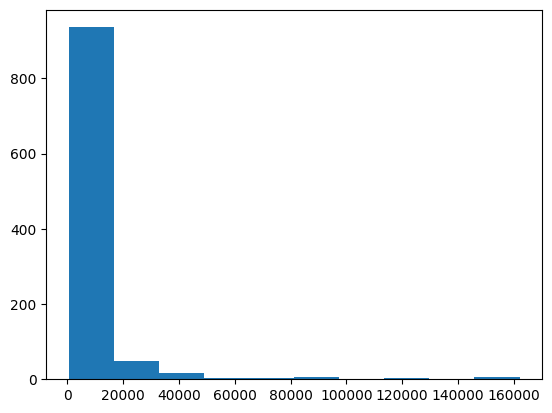

In [68]:
plt.hist(np.sum(X, axis=0))

In [87]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# Setup cross-validation
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# Number of estimators (you can try different values)
n_estimators = [10, 25, 50, 100]

for n in n_estimators:
    for count, (train, test) in enumerate(skf.split(X, y)):
        
        # Initialize HistGradientBoostingClassifier
        clf = HistGradientBoostingClassifier(
            max_iter=n,  # number of boosting iterations (equivalent to n_estimators)
            random_state=42
        )
        
        # Train the model
        print(f"Fitting model with {n} estimators - Split {count}")
        clf.fit(X[train], y[train])
        
        # Calculate AUROC for Train and Test sets
        train_auc = roc_auc_score(y[train], clf.predict_proba(X[train])[:, 1])
        test_auc = roc_auc_score(y[test], clf.predict_proba(X[test])[:, 1])
        
        # Print the results
        print(f"AUROC Train: {train_auc}")
        print(f"AUROC Test: {test_auc}")


Fitting model with 10 estimators - Split 0
AUROC Train: 0.6283108112907749
AUROC Test: 0.5253063527325453
Fitting model with 10 estimators - Split 1
AUROC Train: 0.6246668062166096
AUROC Test: 0.5143550485869239
Fitting model with 10 estimators - Split 2
AUROC Train: 0.6193609027817715
AUROC Test: 0.5347392787106277
Fitting model with 10 estimators - Split 3
AUROC Train: 0.6186444110404962
AUROC Test: 0.5306280749153264
Fitting model with 25 estimators - Split 0
AUROC Train: 0.6879140931428912
AUROC Test: 0.521265816783527
Fitting model with 25 estimators - Split 1
AUROC Train: 0.6657926051273582
AUROC Test: 0.515477293084385
Fitting model with 25 estimators - Split 2
AUROC Train: 0.6840459990241049
AUROC Test: 0.5353638669655238
Fitting model with 25 estimators - Split 3
AUROC Train: 0.6561729939237491
AUROC Test: 0.5292883176706199
Fitting model with 50 estimators - Split 0
AUROC Train: 0.6879140931428912
AUROC Test: 0.521265816783527
Fitting model with 50 estimators - Split 1
AUROC 

In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
C_values = [0.1, 1, 10, 100]

for C in C_values:
    for count, (train, test) in enumerate(skf.split(X, y)):
        clf = LogisticRegression(C=C, max_iter=1000, random_state=42, solver='liblinear')
        clf.fit(X[train], y[train])
        train_auc = roc_auc_score(y[train], clf.predict_proba(X[train])[:, 1])
        test_auc = roc_auc_score(y[test], clf.predict_proba(X[test])[:, 1])
        print(f"AUROC Train: {train_auc}")
        print(f"AUROC Test: {test_auc}")


AUROC Train: 0.6331317361441375
AUROC Test: 0.5326168077385804
AUROC Train: 0.6361917730600803
AUROC Test: 0.5246389759087744
AUROC Train: 0.632081674095144
AUROC Test: 0.537411450055383
AUROC Train: 0.6322690138514768
AUROC Test: 0.5415167730434978
AUROC Train: 0.6350555090155767
AUROC Test: 0.5286474923696736
AUROC Train: 0.6337764705651936
AUROC Test: 0.5301054658247315
AUROC Train: 0.6368394696977766
AUROC Test: 0.5239556353685002
AUROC Train: 0.6326512182085795
AUROC Test: 0.5354621492134114
AUROC Train: 0.6332000798519597
AUROC Test: 0.5389711840758097
AUROC Train: 0.6358368401892074
AUROC Test: 0.5265020020371064
AUROC Train: 0.6337804979156112
AUROC Test: 0.5297361229618807
AUROC Train: 0.6368468310615071
AUROC Test: 0.5238705759805602
AUROC Train: 0.6326403136954337
AUROC Test: 0.5352039157613718
AUROC Train: 0.6332412201698485
AUROC Test: 0.538560432318265
AUROC Train: 0.635852526537386
AUROC Test: 0.5262317700372441
AUROC Train: 0.6337791499523298
AUROC Test: 0.5296850096302